# How to use $\texttt{erose}$

This notebook provides an example on how to use $\texttt{erose}$ (Enhancing Rapidly Overdensities of Sources with Ease). For details on how the algorithm works, see Rusterucci et al. (2026).

Running this notebook requieres:
- $\texttt{erose}$ (see the [GitHub](https://github.com/samuelrusterucci/erose) to install)
- The "decam_feh2_2_a13.dat" file, available [on GitHub](https://github.com/samuelrusterucci/erose/examples/demo/data)
- The "des_data.parquet" file, available [on Seafile](https://github.com/samuelrusterucci/erose/examples/demo/data)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import erose

In [2]:
import lisamalplotlib as lsm

### The algorithm can be summarised as three modules that can either be used in tandem or independently:

#### 1) Isochrone selection

#### 2) Spatial enhancement

#### 3) Full sky search

___
___

## 1) Isochrone selection

Searching for dwarf galaxies most often makes use of cuts in the colour-magnitude diagram (CMD). We aim to

(a) estimate the typical photometric uncertainties as a function of magnitude

(b) input an isochrone

(c) to weight stars according to their probability of belonging to an input isochrone taken from the $\texttt{parsec}$ library

In the following, as an example we use a subset from the DES Y6 Gold catalogue (whose full version is available at [NoirLab](https://datalab.noirlab.edu/data-explorer?showTable=des_dr2.y6_gold)) containing stars that were selected by applying the cuts from Section 2.1 from [Tan et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025arXiv250912313T/abstract). We only keep essential columns (positions and $g$, $r$, $i$ magnitudes + uncertainties) that will be used in this example, and select stars within a 5 deg radius centred on ($\texttt{R.A.}$, $\texttt{Dec.}$) = ($358.0$, $-61.5$).

In [ ]:
des_data = pd.read_parquet('.data/des_data.parquet')
des_data

,ra,dec,psf_mag_aper_8_g_corrected,psf_mag_aper_8_r_corrected,psf_mag_aper_8_i_corrected,psf_mag_err_aper_8_g,psf_mag_err_aper_8_r,psf_mag_err_aper_8_i
0,2.475671,-58.799984,21.629545,20.321656,19.659513,0.006282,0.002439,0.002164
1,355.983093,-58.799977,25.936408,24.224535,23.197177,0.337863,0.084946,0.058260
2,3.847019,-58.799956,22.510469,21.119628,19.714757,0.012970,0.004403,0.002216
3,3.927215,-58.799954,25.001462,23.515699,21.952239,0.136678,0.040520,0.017714
4,1.222418,-58.799951,24.930813,24.373507,24.361365,0.133772,0.098158,0.147313
...,...,...,...,...,...,...,...,...
1305263,1.468482,-57.300085,21.488586,20.064723,18.837282,0.005220,0.001920,0.001249
1305264,2.175936,-57.300047,23.614333,22.192542,21.038493,0.036070,0.011795,0.006017
1305265,2.388251,-57.300024,27.294814,25.572706,24.883896,1.118213,0.283825,0.218618
1305266,356.944819,-57.300020,25.038223,24.412563,23.886212,0.171798,0.115125,0.114086


___
### Estimating the photometric uncertainties

(a) The `ExponentialFitting` from $\texttt{erose}$ allows us to (as the name gives it away) fit the estimated photometric uncertainties as a function of magnitude for each of the bands. It essentially warps the $\texttt{curve\_fit}$ function from the $\texttt{scipy.optimize}$ submodule to fit an exponential function as it usually fits the uncertainties reasonably well ([see Ibata et al. 2007](https://ui.adsabs.harvard.edu/abs/2007ApJ...671.1591I/abstract)). 

Before initialising `ExponentialFitting`, one should always check that the data ressembles an exponential, otherwise $\texttt{curve\_fit}$ won't converge, and an error might be returned. For each photometric band we define a mask which removes stars that are either too faint or with uncertainties rendering them useless. 

NOTE: the input to `ExponentialFitting` mustn't contain any NaNs.

In [4]:
des_data = des_data.dropna()

g_mask = (des_data['psf_mag_aper_8_g_corrected'] > 18
     ) & (des_data['psf_mag_aper_8_g_corrected'] < 27
     ) & (des_data['psf_mag_err_aper_8_g'] < 10)

r_mask = (des_data['psf_mag_aper_8_r_corrected'] > 18
     ) & (des_data['psf_mag_aper_8_r_corrected'] < 27
     ) & (des_data['psf_mag_err_aper_8_r'] < 10)

i_mask = (des_data['psf_mag_aper_8_i_corrected'] > 18
     ) & (des_data['psf_mag_aper_8_i_corrected'] < 27
     ) & (des_data['psf_mag_err_aper_8_i'] < 10)

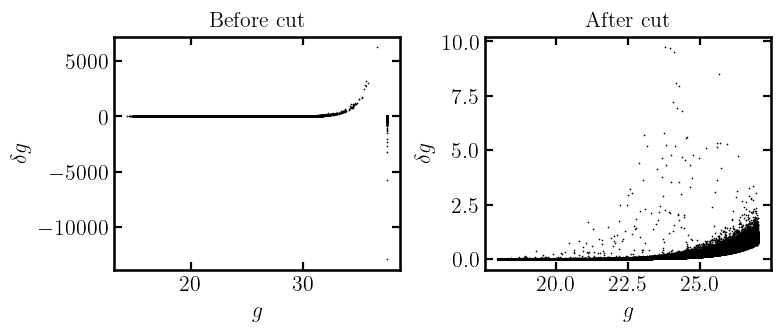

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(7, 2.5), dpi=121)

ax[0].scatter(des_data['psf_mag_aper_8_g_corrected'], 
            des_data['psf_mag_err_aper_8_g'], c='black', s=1, linewidths=0)
ax[0].set_xlabel(r'$g$') ; ax[0].set_ylabel(r'$\delta g$')
ax[0].set_title('Before cut', fontsize=13)

ax[1].scatter(des_data['psf_mag_aper_8_g_corrected'][g_mask], 
            des_data['psf_mag_err_aper_8_g'][g_mask], c='black', s=1, linewidths=0)
ax[1].set_xlabel(r'$g$') ; ax[1].set_ylabel(r'$\delta g$')
ax[1].set_title('After cut', fontsize=13)

fig.subplots_adjust(wspace=0.3)
plt.show()

Once we are happy with our selection, we can apply them on our data and proceed with our exponential fits.

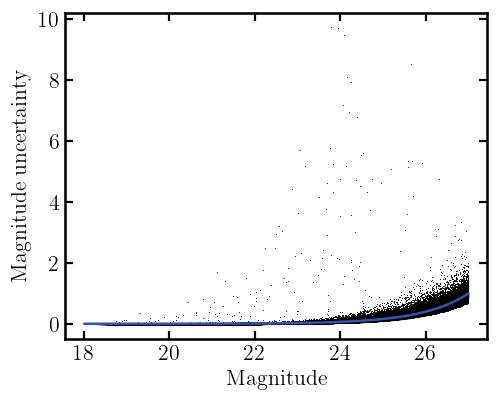

In [6]:
#Masking the input data
des_data = des_data[g_mask & r_mask & i_mask].reset_index(drop=True)

#Creation of an ExponentialFitting object
g = erose.ExponentialFitting(des_data['psf_mag_aper_8_g_corrected'], 
                             des_data['psf_mag_err_aper_8_g'])
g.visualiser() #visualising method

r = erose.ExponentialFitting(des_data['psf_mag_aper_8_r_corrected'], 
                             des_data['psf_mag_err_aper_8_r'])

i = erose.ExponentialFitting(des_data['psf_mag_aper_8_i_corrected'], 
                             des_data['psf_mag_err_aper_8_i'])

By calling the `save_method` from our created `ExponentialFitting` objects, we can save the fits in the current directory in the right format using:

In [ ]:
g.save_model('./data/g_uncertainties')

r.save_model('./data/r_uncertainties')

i.save_model('./data/i_uncertainties')

___ 

### Input an isochrone

(b) As previously mentioned, in order to weight the stars according to their probability of belonging to an isochrone, one (obviously) needs an input isochrone. This isochrone can either be provided by the user or using $\texttt{erose}$'s built-in method (`open_and_spline_parsec`) that automatically reads and splines $\texttt{parsec}$ isochrones using their output '.dat' files.

Here we demonstrate how to use `open_and_spline_parsec` and how its `nb_steps` parameter can be used to increase the density of points from an input parsec file `decam_feh2_2_a13.dat`.

In [ ]:
input_isochrone = erose.open_and_spline_parsec(
    file_name="./data/decam_feh2_2_a13.dat",
    nb_steps=10
)

input_isochrone_test = erose.open_and_spline_parsec(
    file_name="./data/decam_feh2_2_a13.dat",
    nb_steps=1
)

print("The variable 'input_isochrone' is a", type(input_isochrone))

The variable 'input_isochrone' is a <class 'pandas.core.frame.DataFrame'>


We note that in any case, the isochrone must be stored as a `pd.DataFrame` (default when using the `open_and_spline_parsec`).

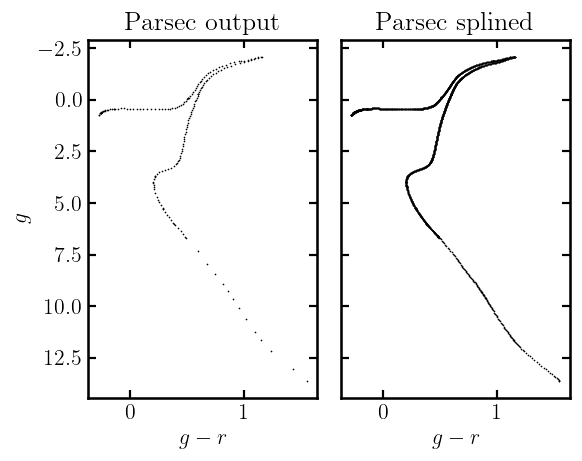

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(5,4), dpi=121, sharey=True)

ax[0].scatter(
    input_isochrone_test['gmag'] - input_isochrone_test['rmag'],
    input_isochrone_test['gmag'], s=1, linewidths=0, c='black'
)
ax[0].invert_yaxis()
ax[0].set_xlabel(r'$g-r$')
ax[0].set_ylabel(r'$g$')
ax[0].set_title('Parsec output')

ax[1].scatter(
    input_isochrone['gmag'] - input_isochrone['rmag'],
    input_isochrone['gmag'], s=1, linewidths=0, c='black'
)
ax[1].set_xlabel(r'$g-r$')
ax[1].set_title('Parsec splined')

fig.tight_layout()
plt.show()

___

### Weighting the stars

(c) Before weighting the stars we need to define a two-dimensional colour-magnitude space, ($g-r$, $g$), the slightly daunting notation is the following:

In [10]:
iso_col_names = {
    "g-r": ["gmag", "rmag"],  #should be interpreted as g - r
    "g":   ["gmag"]           #simple g magnitude
}

input_stars_phot = {
    "g-r": (des_data["psf_mag_aper_8_g_corrected"] - des_data["psf_mag_aper_8_r_corrected"]).to_numpy(),
    "g":   (des_data["psf_mag_aper_8_g_corrected"]).to_numpy()
}

Both are Python dictionaries sharing the **same keys** that can arbitrarily be defined by the user.

- `iso_col_names`: its values list the names from the magnitude columns ofour input isochrone 

- `input_stars_phot`: its values are numpy arrays storing the stars' colours and magnitudes

We also need to provide the algorihtm with the following:

- `phot_uncert`: a dictionary whose keys must match the elements of the lists from `iso_col_names` values. Its values provide the paths to our photometric uncertainty estimates

- `mask_size`: list of the sizes of the mask along each of the axes of the colour space

- `distances_to_probe`: distances to be probed, in kpc

In [ ]:
phot_uncert = {
    "gmag": "./data/g_uncertainties.csv",
    "rmag": "./data/r_uncertainties.csv",
}

mask_size = [0.05, 0.05]

#The probabilities for 16 different isochrone shifts will be computed
distances_to_probe = 10**np.linspace(4, 6, 16)/1000
distances_to_probe = np.round(distances_to_probe, 2)
print("Distances probed (in kpc):", distances_to_probe)

Distances probed (in kpc): [  10.     13.59   18.48   25.12   34.15   46.42   63.1    85.77  116.59
  158.49  215.44  292.86  398.11  541.17  735.64 1000.  ]


Finally we can create an `IsochroneSelector` object using all of the previously defined variables. We can then compute masks and weigths in parallel for the 16 different distances by calling the `masks_and_probs_joblib` method.

In [12]:
IS_obj = erose.IsochroneSelector(
    distances=distances_to_probe,
    isochrone_table=input_isochrone,
    isochrone_colour_mag=iso_col_names,
    input_stars_colour_mag=input_stars_phot,
    paths_to_uncertainties=phot_uncert, #can also be set to None
    mask_size=mask_size,
    cmd_correlation=True
)

# Parallel computing - when multiple distances 
_, probs = IS_obj.masks_and_probs_joblib()
# _, probs = IS_obj.masks_and_probs_multiprocessing() 

#Single task - one unique distance
# _, probs = IS_obj.masks_and_probs()

`masks_and_probs_joblib` returns two dictionaries, but for now we will only be interested in the second one, here named `probs`. The keys of this dictionary are the input distances in kpc (hence justifying why we rounded them). The dictionary's values are numpy arrays whose lengths are the total number of input stars, that correspond to the probabilities of belonging to the isochrone.

In [13]:
print(f'The keys are: {probs.keys()}')

print(f'Probabilities of stars belonging to an isochrone shifted to 10 kpc,', probs['10.0'])

The keys are: dict_keys(['10.0', '13.59', '18.48', '25.12', '34.15', '46.42', '63.1', '85.77', '116.59', '158.49', '215.44', '292.86', '398.11', '541.17', '735.64', '1000.0'])
Probabilities of stars belonging to an isochrone shifted to 10 kpc, [1.26432415e-77 4.50807702e-04 3.26423369e-66 ... 1.18142646e-36
 9.51353893e-04 1.25192846e-37]


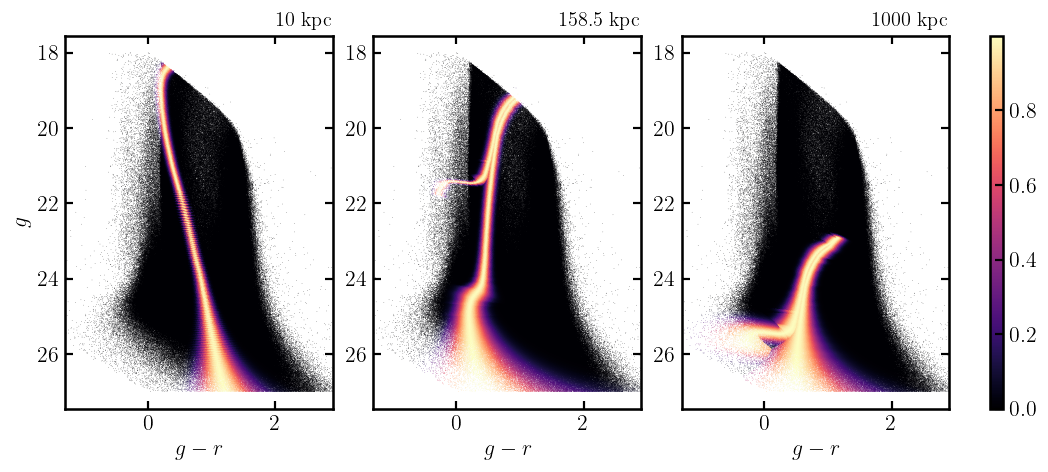

In [14]:
fig, ax = plt.subplots(ncols=4, gridspec_kw={"width_ratios":[1, 1, 1, 0.05]},
                       figsize=(10,4), dpi=121)

pcm = ax[0].scatter(input_stars_phot['g-r'], input_stars_phot['g'], c=probs['10.0'],
                 s=0.1, linewidths=0, cmap='magma')
ax[0].set_xlim(-1.3, 2.9)  ; ax[0].invert_yaxis()
ax[0].set_xlabel(r'$g-r$') ; ax[0].set_ylabel(r'$g$')
ax[0].set_title('10 kpc', loc='right', fontsize=12)

ax[1].scatter(input_stars_phot['g-r'], input_stars_phot['g'], c=probs['158.49'],
                 s=0.1, linewidths=0, cmap='magma')
ax[1].set_xlim(-1.3, 2.9)  ; ax[1].invert_yaxis()
ax[1].set_xlabel(r'$g-r$') 
ax[1].set_title('158.5 kpc', loc='right', fontsize=12)

ax[2].scatter(input_stars_phot['g-r'], input_stars_phot['g'], c=probs['1000.0'],
                 s=0.1, linewidths=0, cmap='magma')
ax[2].set_xlim(-1.3, 2.9)  ; ax[2].invert_yaxis()
ax[2].set_xlabel(r'$g-r$') 
ax[2].set_title('1000 kpc', loc='right', fontsize=12)

fig.colorbar(pcm, cax=ax[3])
plt.show()

___
___

## 2) Spatial enhancement

We choose a field centred on ($\texttt{R.A.}$, $\texttt{Dec.}$) = ($358.0$, $-61.5$) deg which contains Tucana III, IV and V.

We start by instantiating a `ConvolverRunner` object which performs the projection from spherical coordinates to the tangential plane, masks stars outside of the field, and performs essential binnings (evaluating star density and the footprint):

In [15]:
input_ra  = des_data['ra'].to_numpy()
input_dec = des_data['dec'].to_numpy()

CR_obj = erose.ConvolverRunner(
    phi=input_ra, theta=input_dec,
    phi_c=358., theta_c=-61.5, resolution=0.5,
    footprint_resolution=8, span=3.5
)

- `phi`, `theta`: input spherical coordinates of the sources in the data, for example: (ra, dec) or (l, b)

- `phi_c`, `theta_c`: centre of the field where we want to perform a search for overdensities

- `resolution`: resolution of the underlying histogram (that determines the counts), given in arcmin

- `span`: this is simply the size of the field in degrees

- `footprint_resolution`: ratio between the pixels from `resolution` and the bigger ones used to estimate the footprint

Finally we decide the sizes of what we want to enhance by defining:

- `signal_kernels`: sizes of the Gaussian kernels used for the smoothing (enhancement)

- `annulus_kernel`: array listing the inner and outer radii of the annulus used for the estimate of the background density

In [16]:
signal_kernels = np.array([1, 2, 4, 8, 16])

annulus_kernel = np.array([96, 200]) #inside and outside radii

Note: in both cases the values are provided in pixels. This means that if `resolution = 0.5`, as defined above, a kernel size of 1 will correspond to 0.5'.

Using the `launch_erose` and `visualiser` methods we can launch $\texttt{erose}$ and visualise the output.

Convolution in progress, please wait an instant:   0%|          | 0/5 [00:00<?, ?it/s]

Convolution in progress, please wait an instant: 100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


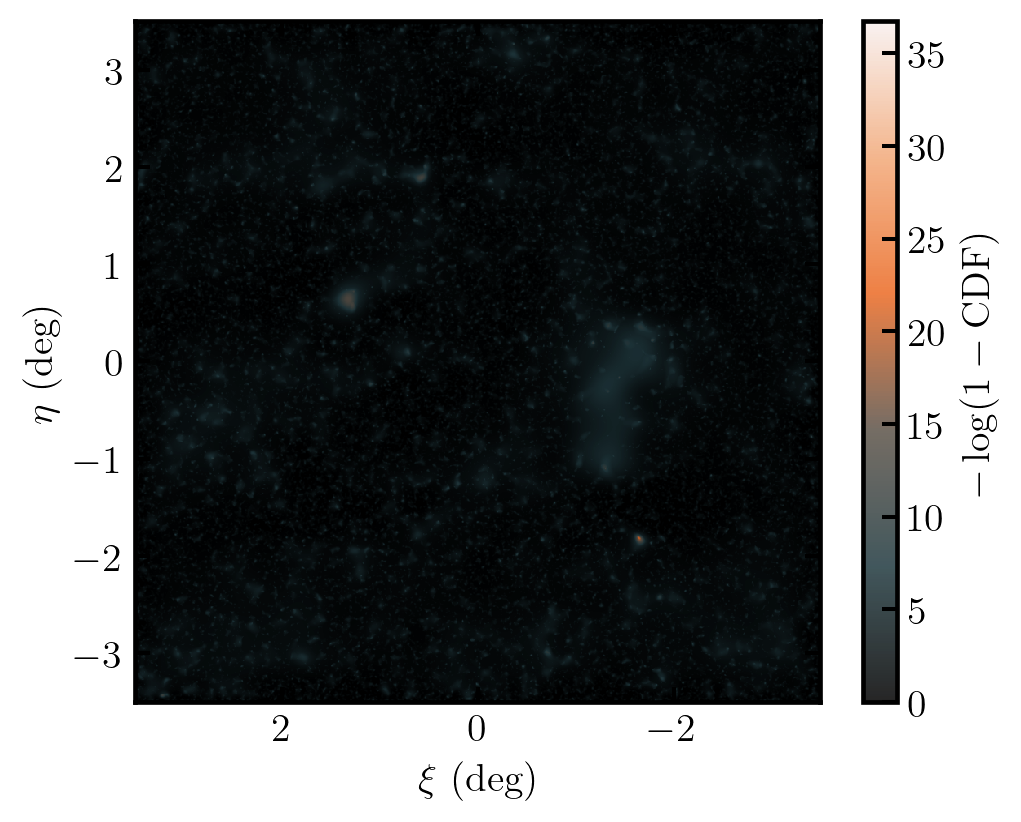

In [17]:
CR_obj.launch_erose(
    signal_kernel_sizes=signal_kernels,
    background_annulus_size=annulus_kernel,
    progress_bar=True,
)

CR_obj.visualiser()

We barely notice any overdensities which doesn't come as a surprise as Tucana III, IV and V all have low surface brightnesses, their member stars being overwhelmingly drowned by the sheer number of foreground Milky Way stars. 

Now we account for the photometry of the stars using a three-dimensional (multi-)colour-magnitude space: ($g-r$, $r-i$, $g$), that can be defined as before

In [ ]:
iso_col_names = {
    "g-r": ["gmag", "rmag"],  #first colour 
    "r-i": ["rmag", "imag"],  #second colour 
    "g":   ["gmag"]           #magnitude
}

#We note the use of CR_obj.region_mask, so only the probabilities of stars 
#in the field are computed
input_stars_phot = {
    "g-r": np.array(des_data["psf_mag_aper_8_g_corrected"] - des_data["psf_mag_aper_8_r_corrected"])[CR_obj.region_mask],
    "r-i": np.array(des_data["psf_mag_aper_8_r_corrected"] - des_data["psf_mag_aper_8_i_corrected"])[CR_obj.region_mask],
    "g":   np.array(des_data["psf_mag_aper_8_g_corrected"])[CR_obj.region_mask]
}

phot_uncert = {
    "gmag": "./data/g_uncertainties.csv",
    "rmag": "./data/r_uncertainties.csv",
    "imag": "./data/i_uncertainties.csv"
}

mask_size = [0.05, 0.05, 0.05]

#The probabilities for 16 different isochrone shifts will be computed
distances_to_probe = 10**np.linspace(4, 6, 16)/1000
distances_to_probe = np.round(distances_to_probe, 2)

IS_obj = erose.IsochroneSelector(
    distances=distances_to_probe,
    isochrone_table=input_isochrone,
    isochrone_colour_mag=iso_col_names,
    input_stars_colour_mag=input_stars_phot,
    paths_to_uncertainties=phot_uncert,
    mask_size=mask_size,
    cmd_correlation=True
)

_, probs = IS_obj.masks_and_probs_joblib()

Convolution in progress, please wait an instant:   0%|          | 0/80 [00:00<?, ?it/s]

Convolution in progress, please wait an instant: 100%|██████████| 80/80 [00:45<00:00,  1.76it/s]


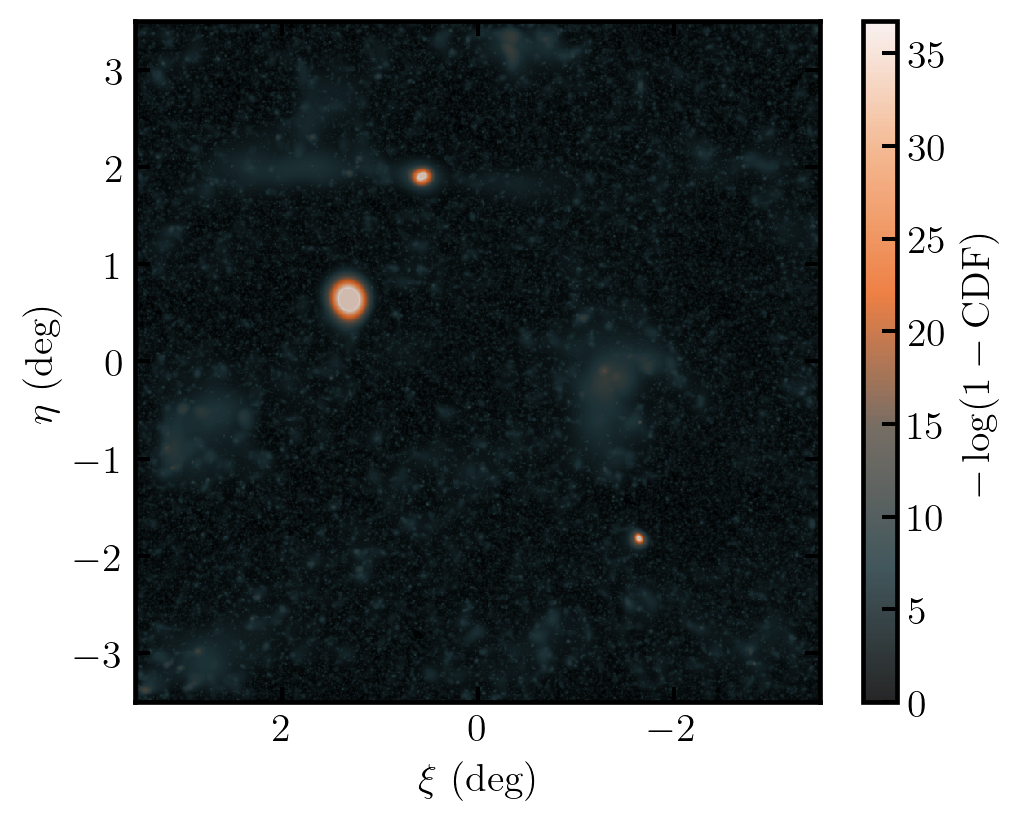

In [19]:
CR_obj.launch_erose(
    signal_kernel_sizes=signal_kernels,
    background_annulus_size=annulus_kernel,
    isochrone_weights=probs,
    progress_bar=True,
)

CR_obj.visualiser()

Great... we found the overdensities! In order to isolate them we can create a `BlobExtractor` object and simply pass as argument our `ConvolverRunner` object. 

In [15]:
BE_obj = erose.BlobExtractor(CR_obj, threshold=15)

Everything having been computed, we can display the blobs that have been extracted using the `field_visualiser` method:

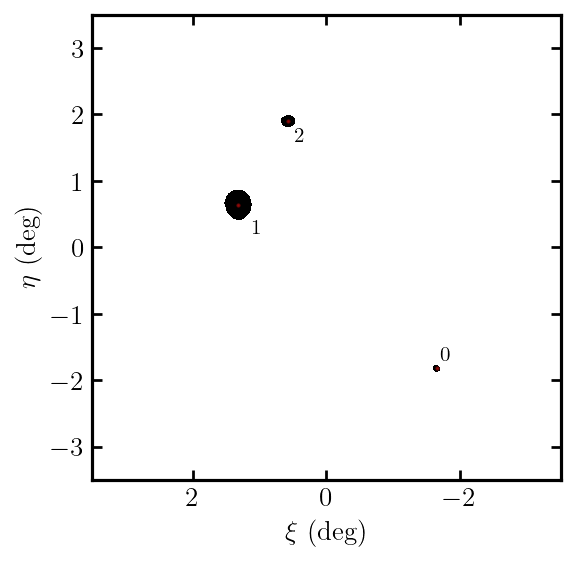

In [16]:
BE_obj.field_visualiser()

and we can also access the extracted properties of the blobs through the `blob_properties` variable:

In [17]:
print(BE_obj.blob_properties)

   peak_max      ra    dec blob_dist  blob_size  noise_com  field_edg  nb_src
0     36.74  354.33 -63.27     46.42        2.0       1.00          0      39
1     36.74  360.71 -60.83     46.42        8.0       1.00          0     266
2     36.74  359.14 -59.60     25.12        4.0       0.99          0     117



- peak_max: is a measurement of the significance of a detection according to the algorithm, ranging from 0 to 36.74. Depending on the survey, false positives appear below ~18-20.

- ra, dec: are the coordinates of the centre of the blob

- blob_dist and blob_size: are the estimates of the distance (in kpc) and the size (in arcmin) of the overdensity

- noise_com: is the measurement of the fraction of the background annulus contained within the footprint (below 0.3, the background estimate becomes unreliable)

- field_edg: is a flag equal to 1 if the detection is within 0.5 deg from the field edge (this value can be changed when creating our blob object by modifying the 'field_edge_value' parameter)

- nb_src: is the number of sources within the pixels associated to an overdensity that are above the threshold

The "default" output diagnostic plot is the following: displaying the spatial distribution of the stars along with two CMDs, one of the candidate (central blue circle) and one from a surrounding region (surrounding blue annulus):

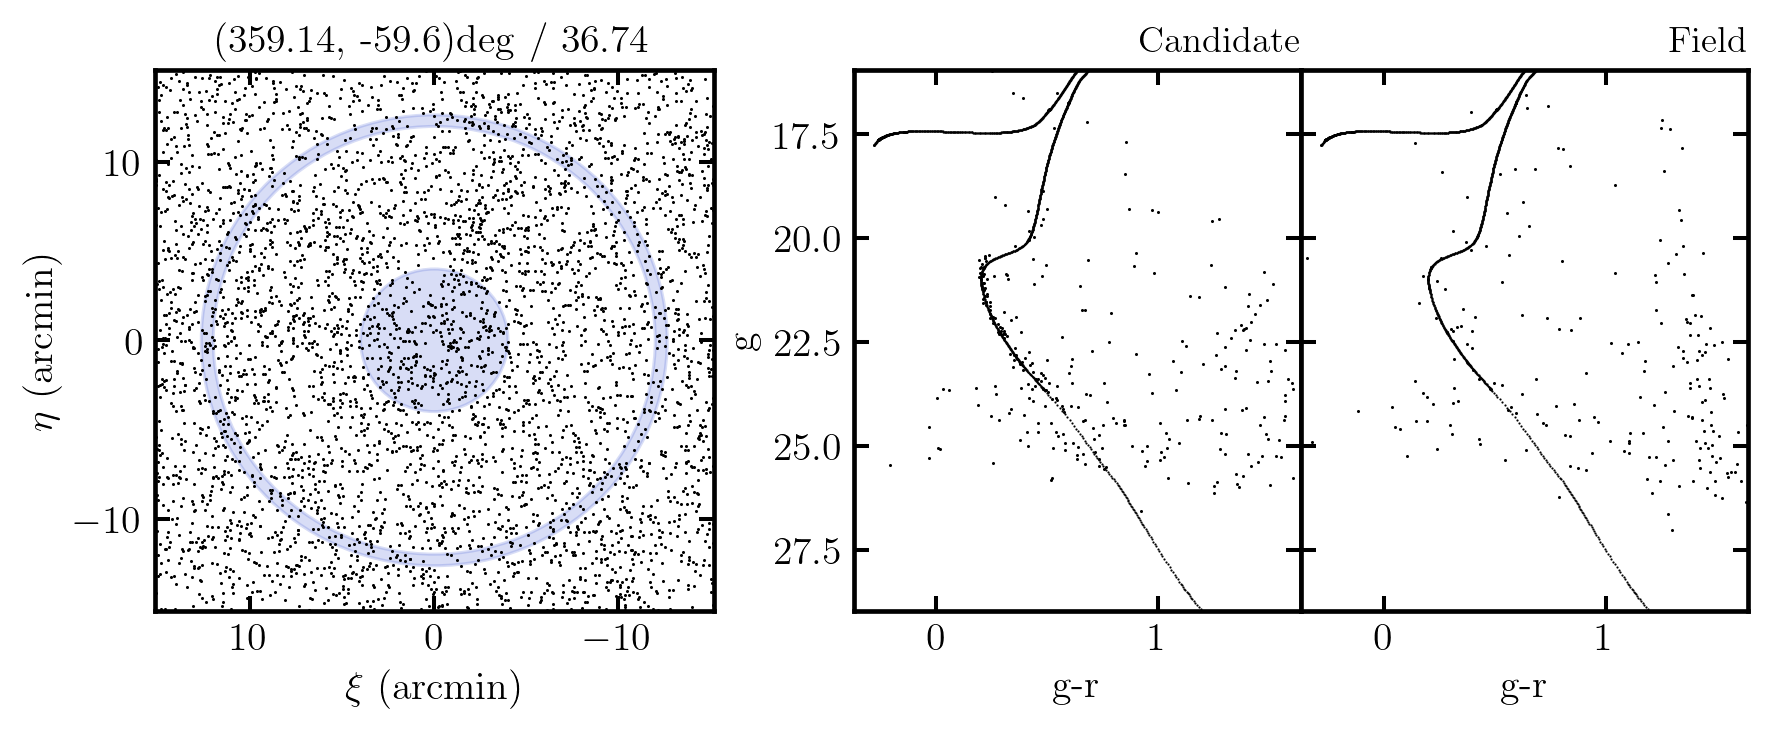

In [25]:
BE_obj.diagnostic_plot(
    blob_id=2, 
    IS_obj=IS_obj, 
    # blob_size=10,
    # min_col_cmd=0, 
    # max_col_cmd=1,
    # min_mag_cmd=21, 
    # max_mag_cmd=26,
    # colour_label=r'$g-r$',
    # mag_label=r'$g$',
    # s=10
)

- `blob_id`: this is the index of the blob provided in `BE_obj.blob_properties`.

- `IS_obj`: this objects is the one that stored both the isochrone and the positions of the stars in the CMD

- `blob_size`: by default, the central region will be 1.5 $\times$ estimated size of the blob returned in `BE_obj.blob_properties`. This value can be changed to any other (in arcmin)

- `min_col_cmd` and `max_col_cmd`: minimum and maximum colours plotted on the CMD

- `min_mag_cmd` and `max_mag_cmd`: minimum and maximum magnitudes plotted on the CMD

- `colour_label` and `mag_label`: labels given to the x and y axis of the CMD

- `s`: size of the points

___
___

## 3) Full sky search

There are two different ways to run the full sky search:

- Using parquet files, necessary if your RAM is limited
- Using any type of input file as long as it can be loaded in Python and then stored as a numpy array (not containing any NaN or inf)

In our case, having already loaded our DES data at the beginning of the Notebook, we start by giving a practical example of the second method, and later provided an example with parquet.

The inputs required to run the algorithms are the same as before:

In [ ]:
#For the isochrone selection

iso_col_names = {
    "g-r": ["gmag", "rmag"],  #first colour 
    "r-i": ["rmag", "imag"],  #second colour 
    "g":   ["gmag"]           #magnitude
}

input_stars_phot = {
    "g-r": (des_data["psf_mag_aper_8_g_corrected"] - des_data["psf_mag_aper_8_r_corrected"]).to_numpy(),
    "r-i": (des_data["psf_mag_aper_8_r_corrected"] - des_data["psf_mag_aper_8_i_corrected"]).to_numpy(),
    "g":   (des_data["psf_mag_aper_8_g_corrected"]).to_numpy()
}

phot_uncert = {
    "gmag": "./data/g_uncertainties.csv",
    "rmag": "./data/r_uncertainties.csv",
    "imag": "./data/i_uncertainties.csv"
}

mask_size = [0.05, 0.05, 0.05]

distances_to_probe = 10**np.linspace(4, 6, 16)/1000
distances_to_probe = np.round(distances_to_probe, 2)

#For the spatial enhancement
input_ra  = des_data['ra'].to_numpy()
input_dec = des_data['dec'].to_numpy()

signal_kernels = np.array([1, 2, 4, 8, 16])
annulus_kernel = np.array([96, 200]) 

In order to automatically run the algorithm on the entire sky we need to instantiate a `SurveyRunner` object which first tessellates the sky into the fields that are going to be used to run our searches. The space between the centres of those fields can be modified using the `inter_field_span` parameter.

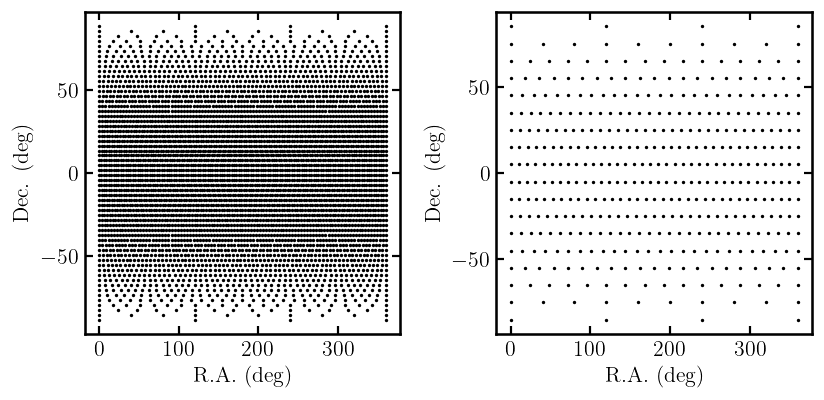

In [32]:
SR_obj1 = erose.SurveyRunner(
    inter_field_span=3.0,
)

SR_obj2 = erose.SurveyRunner(
    inter_field_span=10.0,
)

fig, ax = plt.subplots(1, 2, figsize=(7, 3.5), dpi=121)
ax[0].scatter(SR_obj1.ra_overdensity_field, 
            SR_obj1.dec_overdensity_field, s=1)

ax[0].set_xlabel('R.A. (deg)')
ax[0].set_ylabel('Dec. (deg)')

ax[1].scatter(SR_obj2.ra_overdensity_field, 
            SR_obj2.dec_overdensity_field, s=1)
ax[1].set_xlabel('R.A. (deg)')
ax[1].set_ylabel('Dec. (deg)')

fig.tight_layout()
plt.show()

Another important parameter of `SurveyRunner` is `available_memory`, which can be set to 'low', 'medium' or 'high'. To understand what it does, we remind that the weigths of the stars (computed in 1) Isochrone selection) are stored in a dictionary of numpy arrays. Having about one million stars in our input catalogue and probing 16 different distances, the size (in GB) of the resulting 16 arrays can be estimated using:

In [33]:
erose.isochrone_cutter.estimated_memory_required()

Expected memory usage: 0.11921 GB


As our input catalogue is relatively small, the memory required to store those weights also is (~0.12GB). However, this can become a problem for bigger catalogues or if more distance shifts are probed. This is why we have the three different modes for `available_memory`:

- 'high': on principle the fastest mode as all the weights for all the stars from the catalogue are computed once, however it will take a lot of RAM.

- 'medium': instead of computing the weigths for the whole catalogue, computes the weigths in one declination stripe (height corresponding to the span of the fields). This mode is slightly slower as the weights of stars contained within overlapping declination stripes will be computed twice.

- 'low': slowest but best RAM efficient mode as only the weights of the current field are storred.

To run a full sky search `SurveyRunner` class. We note that `isochrone_selector` and `convolver_runner` are methods from the `SurveyRunner` class that can be interpreted as wrappers of their homonym classes `IsochroneSelector` and `ConvolverRunner` classes (as they share almost the same arguments). 

In [ ]:
SR_obj = erose.SurveyRunner(
    inter_field_span=8.0,
    available_memory='high'
)

SR_obj.isochrone_selector(
    distances=distances_to_probe,
    isochrone_table=input_isochrone,
    isochrone_colour_mag=iso_col_names,
    input_stars_colour_mag=input_stars_phot,
    paths_to_uncertainties=phot_uncert,
    mask_size=mask_size,
    # mode='multiprocessing'  #joblib by default but multiprocessing can also be used
)

SR_obj.convolver_runner(
    phi=input_ra,
    theta=input_dec,
    resolution=0.5,
    footprint_resolution=8.0,
    span=7,
)

SR_obj.launch_full_sky_search(
    signal_kernel_sizes=signal_kernels,
    background_annulus_size=annulus_kernel,
    diagnostic_plots=True, #diagnostic plots are made or not
)

Everything ran correctly.                      
Fields treated: 100%|██████████| 640/640 [03:34<00:00,  2.99it/s,  ]


Finally we get to the parquet file option, which should be used if even the catalogue is too big to be loaded in. The notation is almost the same except for `input_star_colours`, `input_ra` and `input_dec` slightly changes. Instead of passing the arrays storing the values from the loaded catalogue, only the column names are necessary.

In [ ]:
colour_space = {
    "g-r": ["gmag", "rmag"],  #first colour 
    "r-i": ["rmag", "imag"],  #second colour 
    "g":   ["gmag"]           #magnitude
}

input_star_colours = {
    "g-r": ["psf_mag_aper_8_g_corrected", "psf_mag_aper_8_r_corrected"], # <--- CHANGES 
    "r-i": ["psf_mag_aper_8_r_corrected", "psf_mag_aper_8_i_corrected"], # <--- CHANGES 
    "g":   ["psf_mag_aper_8_g_corrected"]                                # <--- CHANGES 
}

phot_uncert = {
    "gmag": "./data/g_uncertainties.csv",
    "rmag": "./data/r_uncertainties.csv",
    "imag": "./data/i_uncertainties.csv"
}

mask_size = [0.05, 0.05, 0.05]

distances_to_probe = 10**np.linspace(4, 6, 16)/1000
distances_to_probe = np.round(distances_to_probe, 2)

#For the spatial enhancement
input_ra  = {'ra': 'ra'}       # <--- CHANGES 
input_dec = {'dec': 'dec'}     # <--- CHANGES 

signal_kernels = np.array([1, 2, 4, 8, 16])
annulus_kernel = np.array([96, 200]) 

In this mode, `SurveyRunner` requires an additional parameter `parquet_file_name` providing the path and name of the file.

Additionally, one can add cuts following the Pandas [read_parquet](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html) format (those cuts are perfomed before loading in the data).

In [ ]:
SR_obj = erose.SurveyRunner(
    inter_field_span=8.0,
    available_memory='high',
    parquet_file_name='des_data.parquet',
    additional_cut=[('psf_mag_aper_8_g_corrected', '>', 18), ('psf_mag_aper_8_g_corrected', '<', 27), ('psf_mag_err_aper_8_g', '<', 10
                 ) , ('psf_mag_aper_8_r_corrected', '>', 18), ('psf_mag_aper_8_r_corrected', '<', 27), ('psf_mag_err_aper_8_r', '<', 10
                 ) , ('psf_mag_aper_8_i_corrected', '>', 18), ('psf_mag_aper_8_i_corrected', '<', 27), ('psf_mag_err_aper_8_i', '<', 10)],
    #restrart_from_dec=-61.5, #the search is performed starting from ~-61.5deg in decl.
)

SR_obj.isochrone_selector(
    distances=distances_to_probe,
    isochrone_table=input_isochrone,
    isochrone_colour_mag=colour_space,
    input_stars_colour_mag=input_star_colours,
    paths_to_uncertainties=phot_uncert,
    mask_size=mask_size,
    # mode='multiprocessing'
)

SR_obj.convolver_runner(
    phi={'ra': 'ra'},
    theta={'dec': 'dec'},
    resolution=0.5,
    footprint_resolution=8.0,
    span=5,
)

SR_obj.launch_full_sky_search(
    signal_kernel_sizes=signal_kernels,
    background_annulus_size=annulus_kernel,
    diagnostic_plots=True,
)

Everything ran correctly.                      
Fields treated: 100%|██████████| 640/640 [03:31<00:00,  3.03it/s,  ]
